In [1]:
import sys
sys.path.append('..')

import torch
import numpy as np
import json
import gc
from tqdm import tqdm
from datasets import load_dataset
import matplotlib.pyplot as plt

from src.model_loader import load_model


In [2]:
# ---------------------------------------------------------------------------
# Globals
# ---------------------------------------------------------------------------
CHECKPOINTS = {
    "GradDiff": "open-unlearning/unlearn_tofu_Llama-3.2-1B-Instruct_forget10_GradDiff_lr1e-05_alpha5_epoch5",
    "NPO":      "open-unlearning/unlearn_tofu_Llama-3.2-1B-Instruct_forget10_NPO_lr1e-05_beta0.5_alpha1_epoch10",
    "AltPO":    "open-unlearning/unlearn_tofu_Llama-3.2-1B-Instruct_forget10_AltPO_lr5e-05_beta0.1_alpha1_epoch10",
    "SimNPO":   "open-unlearning/unlearn_tofu_Llama-3.2-1B-Instruct_forget10_SimNPO_lr2e-05_b4.5_a1_d1_g0.125_ep10",
    "RMU":      "open-unlearning/unlearn_tofu_Llama-3.2-1B-Instruct_forget10_RMU_lr5e-05_layer10_scoeff10_epoch10",
}

RETAIN = "open-unlearning/tofu_Llama-3.2-1B-Instruct_retain90"
BASE_MODEL = "open-unlearning/tofu_Llama-3.2-1B-Instruct_full"

OUTPUT_DIR = "../results/baseline_logprobs/"


In [3]:
def get_target_logprob(model, tokenizer, question, target_answer, device):
    prompt = f"Question: {question}\nAnswer:"
    full_text = f"{prompt} {target_answer}" # Add the space if your dataset uses it
    
    # Tokenize everything together
    full_input_ids = tokenizer(full_text, return_tensors="pt").input_ids.to(device)
    prompt_ids = tokenizer(prompt, return_tensors="pt").input_ids.to(device)
    
    # Calculate exactly where the prompt ends
    prompt_length = prompt_ids.shape[1]
    
    with torch.no_grad():
        outputs = model(full_input_ids)
            
    logits = outputs.logits[0] 
    
    # The first token we want to predict is at prompt_length
    # To predict the token at index 'i', we need the logit from index 'i-1'
    target_logits = logits[prompt_length - 1 : -1, :] 
    target_ids_flat = full_input_ids[0, prompt_length:]
    
    log_probs = torch.nn.functional.log_softmax(target_logits, dim=-1)
    target_log_probs = log_probs[torch.arange(target_logits.shape[0]), target_ids_flat]
    
    if target_log_probs.dim() == 0:
        return target_log_probs.item()
        
    return target_log_probs.mean().item()

def run_baseline_sweep():
    print("Loading datasets...")
    # Load forget10
    forget_dataset = load_dataset("locuslab/TOFU", "forget10")["train"]
    forget_qs, forget_ans = forget_dataset["question"], forget_dataset["answer"]
    
    # Build a master dict of all models to evaluate
    models_to_eval = {
        "Base Model": BASE_MODEL,
        "Retain Oracle": RETAIN,
        **CHECKPOINTS
    }
    
    results = {}
    
    for label, path in models_to_eval.items():
        print(f"\n--- Evaluating {label} ---")
        model, tokenizer, device = load_model(path)
        
        logprobs = []
        for q, a in tqdm(zip(forget_qs, forget_ans), total=len(forget_qs), desc=f"{label} (Forget)"):
            lp = get_target_logprob(model, tokenizer, q, a, device)
            logprobs.append(lp)
            
        results[label] = {
            "mean_logprob": np.mean(logprobs),
            "std_logprob": np.std(logprobs),
            "raw_logprobs": logprobs
        }
        
        print(f"[{label}] Mean Log-Prob: {results[label]['mean_logprob']:.4f}")
        
        # Free memory before loading the next checkpoint
        del model
        del tokenizer
        gc.collect()
        if torch.backends.mps.is_available():
            torch.mps.empty_cache()
        elif torch.cuda.is_available():
            torch.cuda.empty_cache()

    # Save numeric results
    with open(OUTPUT_DIR + "/baseline_logprobs.json", "w") as f:
        json.dump(results, f, indent=2)
        
    # Generate visualization
    plt.figure(figsize=(10, 6))
    for label, data in results.items():
        # Using KDE/hist to visualize the distribution of unlearning
        plt.hist(data["raw_logprobs"], alpha=0.5, label=f"{label} (μ={data['mean_logprob']:.2f})", bins=30)
        
    plt.title("Forget Set Knowledge Suppression (Baseline)")
    plt.xlabel("Target Answer Mean Log-Probability")
    plt.ylabel("Number of Questions")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR + "/baseline_distributions.png")
    print("\nSaved baseline_logprobs.json and baseline_distributions.png")

Loading datasets...

--- Evaluating Base Model ---


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

Loaded: open-unlearning/tofu_Llama-3.2-1B-Instruct_full
Device: mps | dtype: torch.float16
Params: 1.2B


Base Model (Forget): 100%|██████████| 400/400 [00:22<00:00, 17.74it/s]


...

[SimNPO] Mean Log-Prob: -1.2908

--- Evaluating RMU ---


Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

Loaded: open-unlearning/unlearn_tofu_Llama-3.2-1B-Instruct_forget10_RMU_lr5e-05_layer10_scoeff10_epoch10
Device: mps | dtype: torch.float16
Params: 1.2B


RMU (Forget): 100%|██████████| 400/400 [00:21<00:00, 18.62it/s]


[RMU] Mean Log-Prob: -8.3253

Saved baseline_logprobs.json and baseline_distributions.png


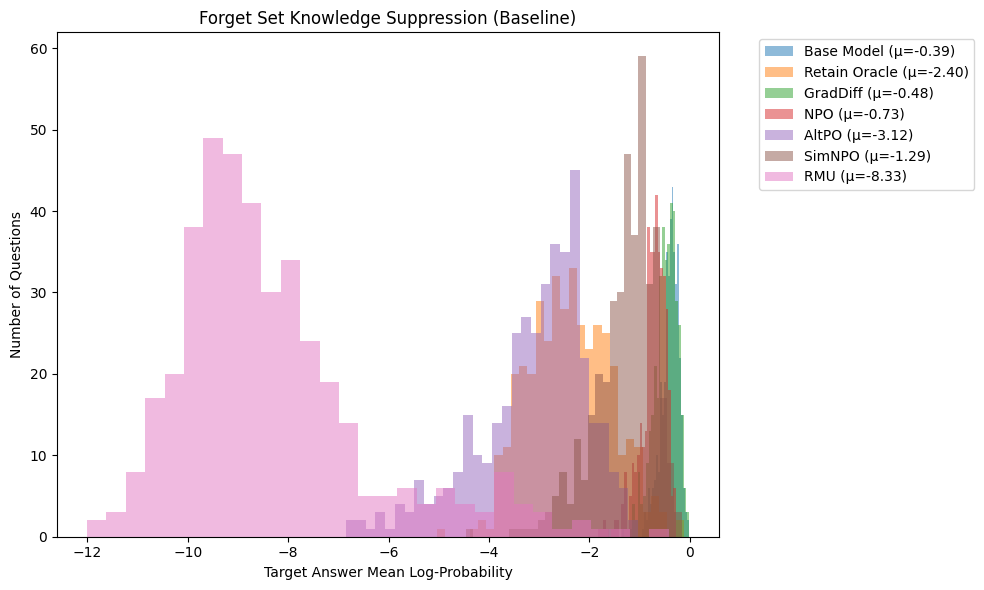

In [4]:
run_baseline_sweep()

=== Retain Oracle Forensic Analysis ===
Total Questions Evaluated : 400
Valid Questions (No NaNs) : 400
Stored Mean in JSON       : -2.3999
True Math Mean of Array   : -2.3999
Min Log-Prob              : -5.0430
Max Log-Prob              : -0.1156

=== All Checkpoint Means in JSON ===
Base Model      : -0.3935
Retain Oracle   : -2.3999
GradDiff        : -0.4823
NPO             : -0.7333
AltPO           : -3.1219
SimNPO          : -1.2908
RMU             : -8.3253


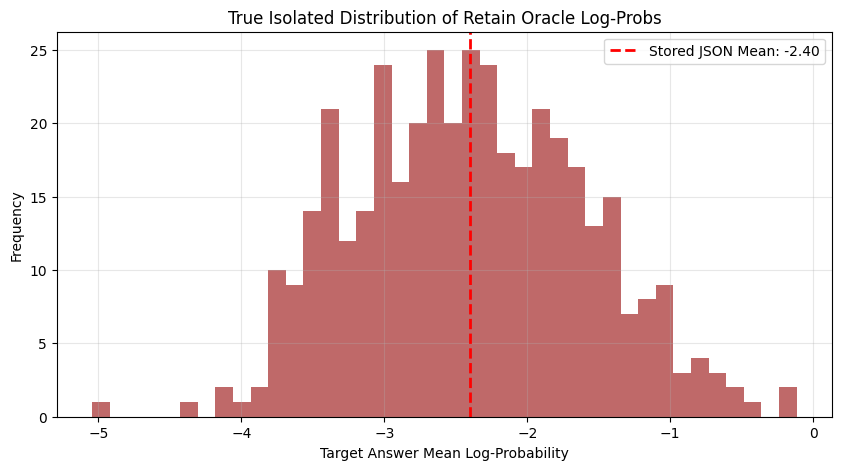

In [6]:
import json
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the JSON data
json_path = OUTPUT_DIR + "/baseline_logprobs.json" # Adjust path if needed
with open(json_path, "r") as f:
    results = json.load(f)

# 2. Deep Dive into SimNPO
target = "Retain Oracle"

if target not in results:
    print(f"Error: {target} not found in the JSON file!")
else:
    data = results[target]
    raw_lps = np.array(data["raw_logprobs"])
    
    # Handle potentially broken numbers (NaNs/Infs) that could skew the mean
    valid_lps = raw_lps[~np.isnan(raw_lps) & ~np.isinf(raw_lps)]
    
    stored_mean = data["mean_logprob"]
    calculated_mean = np.mean(valid_lps)

    print(f"=== {target} Forensic Analysis ===")
    print(f"Total Questions Evaluated : {len(raw_lps)}")
    print(f"Valid Questions (No NaNs) : {len(valid_lps)}")
    print(f"Stored Mean in JSON       : {stored_mean:.4f}")
    print(f"True Math Mean of Array   : {calculated_mean:.4f}")
    print(f"Min Log-Prob              : {np.min(valid_lps):.4f}")
    print(f"Max Log-Prob              : {np.max(valid_lps):.4f}")

    # 3. Who does -1.56 actually belong to?
    print("\n=== All Checkpoint Means in JSON ===")
    for model_name, model_data in results.items():
        print(f"{model_name:<15} : {model_data['mean_logprob']:.4f}")

    # 4. Plot ONLY SimNPO to see the true distribution
    plt.figure(figsize=(10, 5))
    plt.hist(valid_lps, bins=40, color='brown', alpha=0.7)
    
    # Draw vertical lines for the means
    plt.axvline(stored_mean, color='red', linestyle='dashed', linewidth=2, 
                label=f"Stored JSON Mean: {stored_mean:.2f}")
    if abs(stored_mean - calculated_mean) > 0.01:
        plt.axvline(calculated_mean, color='blue', linestyle='dotted', linewidth=2, 
                    label=f"True Math Mean: {calculated_mean:.2f}")

    plt.title(f"True Isolated Distribution of {target} Log-Probs")
    plt.xlabel("Target Answer Mean Log-Probability")
    plt.ylabel("Frequency")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()